# Работа по теме "Методы снижения размерности. Методы кластеризации"

## Описание

Работа предполагает самостоятельное исследование двух наборов данных. Основная задача - показать умение применять и интерпретировать методы снижения размерности данных и методы калстеризации. 

Предлагаются два набора данных из различных областей.

Примерные критерии оценки:

- Данные изучены, предобработаны при необходимости.
- Применяются различные методы снижения размерности данных.
- Объяснены методы снижения размерности.
- Использованы различные методы кластеризации.
- Методы правильно объяснены и применены.
- Полученные кластеры корректно интерпертированы.

Итогом каждого исследования является кластеризация с подробной интерпретацией полученных кластеров.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Анализ клиентов магазина

Датасет `Customer.csv` содержит синтетические данные о клиентах воображаемого магазина.

Набор данных состоит из 2000 записей и 8 столбцов:

- Идентификатор клиента
- Пол
- Возраст
- Годовой доход
- Оценка расходов — оценка, присваиваемая магазином на основе поведения покупателя и характера расходов.
- Профессия
- Опыт работы - в годах
- Размер семьи

Требуется помочь бизнесу лучше понять своих клиентов.

In [3]:
df_cust = pd.read_csv('Customers.csv')
print("Клиенты: размер", df_cust.shape)
df_cust.head()
df_cust_enc = df_cust.drop('CustomerID', axis=1)
cat_cols = ['Gender', 'Profession']
for col in cat_cols:
    df_cust_enc[col] = LabelEncoder().fit_transform(df_cust_enc[col].astype(str))

Клиенты: размер (2000, 8)


In [4]:
features_cust = ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 
                 'Work Experience', 'Family Size'] + cat_cols
x_cust = df_cust_enc[features_cust]
scaler_cust = StandardScaler()
x_cust_scaled = scaler_cust.fit_transform(x_cust)
pca_cust = PCA(n_components=2)
x_cust_pca = pca_cust.fit_transform(x_cust_scaled)
print(f"PCA explained variance: {pca_cust.explained_variance_ratio_}")

PCA explained variance: [0.16455303 0.15072237]


In [5]:
kmeans_cust = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_cust = kmeans_cust.fit_predict(x_cust_scaled)
sil_cust = silhouette_score(x_cust_scaled, labels_cust)
db_cust = davies_bouldin_score(x_cust_scaled, labels_cust)
print(f"KMeans Customer: Silhouette={sil_cust:.3f}, Davies-Bouldin={db_cust:.3f}")

KMeans Customer: Silhouette=0.112, Davies-Bouldin=2.082


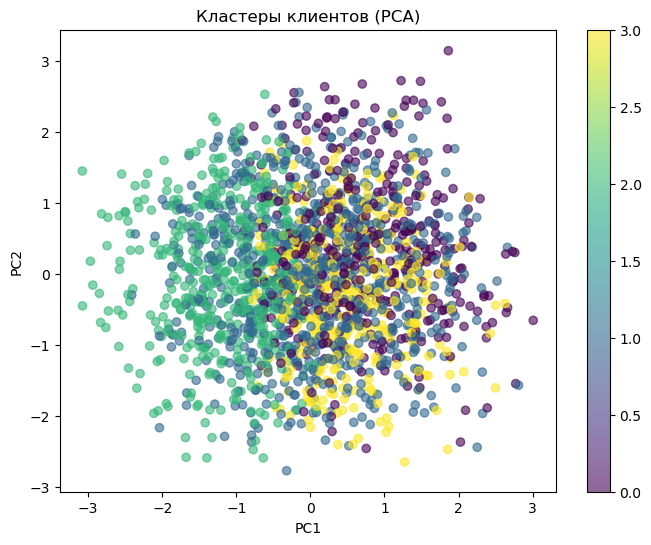

In [6]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(x_cust_pca[:,0], x_cust_pca[:,1], c=labels_cust, cmap='viridis', alpha=0.6)
plt.title('Кластеры клиентов (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
plt.show()

In [7]:
cust_cluster_means = pd.DataFrame(x_cust_scaled, columns=features_cust)
cust_cluster_means['cluster'] = labels_cust
print("\nСредние стандартизированные значения признаков по кластерам:")
print(cust_cluster_means.groupby('cluster').mean())


Средние стандартизированные значения признаков по кластерам:
              Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
cluster                                                                         
0       -0.043699           0.304808               -0.117646         1.316324   
1       -0.001452          -0.018959                0.009743        -0.065580   
2       -0.223420          -0.726525                0.025468        -0.498122   
3        0.325223           0.625215                0.070114        -0.607699   

         Family Size    Gender  Profession  
cluster                                     
0           0.157841 -0.645782   -0.083273  
1          -0.012217  1.207064    0.008870  
2          -0.497188 -0.802416   -0.358373  
3           0.478689 -0.774607    0.512660  


## Климат и болезни

Датасет `climate_disease_dataset.csv` объединяет климатические, экологические, эпидемиологические и социально-экономические данные из 120 стран за 24 года (2000-2023). Целью является анализ взаимосвязи между изменением климата, загрязнением окружающей среды и распространением инфекционных заболеваний (малярия, лихорадка денге, холера, болезнь Лайма).

Требуется провести кластеризацию рисков регионов.

In [8]:
df_clim = pd.read_csv('climate_disease_dataset.csv')
print("\nКлимат: размер", df_clim.shape)
df_clim.head()


Климат: размер (34560, 12)


,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068


In [10]:
agg_cols = ['avg_temp_c', 'precipitation_mm', 'air_quality_index', 'uv_index',
            'malaria_cases', 'dengue_cases', 'population_density', 'healthcare_budget']
df_country = df_clim.groupby('country')[agg_cols].mean().reset_index()
print("Агрегировано по странам:", df_country.shape)

Агрегировано по странам: (120, 9)


In [12]:
x_clim = df_country[agg_cols].values
scaler_clim = StandardScaler()
x_clim_scaled = scaler_clim.fit_transform(x_clim)
pca_clim = PCA(n_components=2)
x_clim_pca = pca_clim.fit_transform(x_clim_scaled)
print(f"PCA климат explained variance: {pca_clim.explained_variance_ratio_}")
tsne_clim = TSNE(n_components=2, random_state=42, perplexity=30)
x_clim_tsne = tsne_clim.fit_transform(x_clim_scaled)

PCA климат explained variance: [0.49948168 0.23554334]


In [14]:
kmeans_clim = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_clim_kmeans = kmeans_clim.fit_predict(x_clim_scaled)
sil_kmeans = silhouette_score(x_clim_scaled, labels_clim_kmeans)
db_kmeans = davies_bouldin_score(x_clim_scaled, labels_clim_kmeans)
print(f"KMeans климат: Silhouette={sil_kmeans:.3f}, Davies-Bouldin={db_kmeans:.3f}")
agg_clim = AgglomerativeClustering(n_clusters=4)
labels_clim_agg = agg_clim.fit_predict(x_clim_scaled)
sil_agg = silhouette_score(x_clim_scaled, labels_clim_agg)
db_agg = davies_bouldin_score(x_clim_scaled, labels_clim_agg)
print(f"Агломеративная: Silhouette={sil_agg:.3f}, Davies-Bouldin={db_agg:.3f}")

KMeans климат: Silhouette=0.279, Davies-Bouldin=1.229
Агломеративная: Silhouette=0.236, Davies-Bouldin=1.319


In [16]:
best_labels_clim = labels_clim_kmeans if sil_kmeans > sil_agg else labels_clim_agg
print(f"Используем кластеры KMeans (silhouette={sil_kmeans:.3f})")

Используем кластеры KMeans (silhouette=0.279)


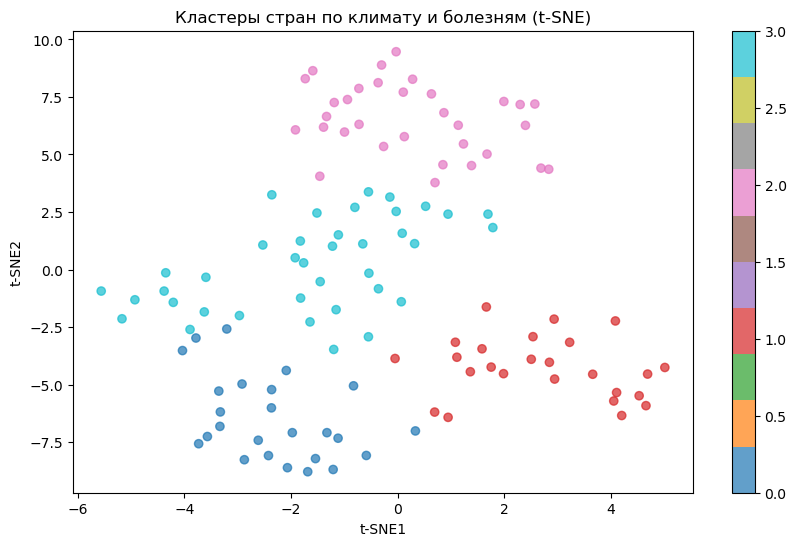

In [17]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(x_clim_tsne[:,0], x_clim_tsne[:,1], c=best_labels_clim, cmap='tab10', alpha=0.7)
plt.title('Кластеры стран по климату и болезням (t-SNE)')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.colorbar(scatter)
plt.show()

In [18]:
clim_means = pd.DataFrame(x_clim_scaled, columns=agg_cols)
clim_means['cluster'] = best_labels_clim
print("\nСредние стандартизированные значения по кластерам (климат):")
print(clim_means.groupby('cluster').mean())


Средние стандартизированные значения по кластерам (климат):
         avg_temp_c  precipitation_mm  air_quality_index  uv_index  \
cluster                                                              
0         -0.914343         -1.007895          -0.864741 -0.936948   
1         -1.028666          0.323863           0.410868 -1.067196   
2          0.677002          0.229189           1.184056  0.693039   
3          0.708189          0.257020          -0.698500  0.734904   

         malaria_cases  dengue_cases  population_density  healthcare_budget  
cluster                                                                      
0            -1.427883     -1.378819           -0.014265           0.874234  
1            -0.144108     -0.524539            0.066030          -0.445138  
2             0.980829      0.970094           -0.512136          -1.156672  
3             0.208244      0.435288            0.397216           0.691740  


In [19]:
df_country['cluster'] = best_labels_clim
print("\nПримеры стран в каждом кластере:")
for c in range(4):
    print(f"Кластер {c}: {df_country[df_country['cluster']==c['country'].values[:5]}")

SyntaxError: closing parenthesis '}' does not match opening parenthesis '[' (1688825233.py, line 4)

## Выводы

Ключевые выводы по задачам